# Batch LVQ-SOM vs. Standard SOM

This notebook compares two prototype-based classifiers built with DBGSOM:

1. **`SomClassifier`** (standard approach): a supervised SOM whose prototypes are placed by the purely density-based SOM update — class labels only enter through majority-vote labelling of each prototype's Voronoi set.
2. **Batch LVQ-SOM** (`BatchLvqSom`): take the fitted SOM and refine its prototypes with the supervised batch LVQ-SOM rule (Kohonen 2001, sec. 6.11). Samples of the "wrong" class *repel* a prototype, samples of its own class attract it — nudging prototypes away from class boundaries.

The LVQ refinement should help exactly where classes overlap: prototypes near a boundary get pushed to the majority side of it.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

from dbgsom import BatchLvqSom, SomClassifier

warnings.filterwarnings("ignore", category=UserWarning)

## Dataset: Overlapping Gaussian Blobs

Five 2-D Gaussian clusters with `cluster_std=3.0` — enough overlap that the Bayes error is clearly nonzero and boundary placement matters.

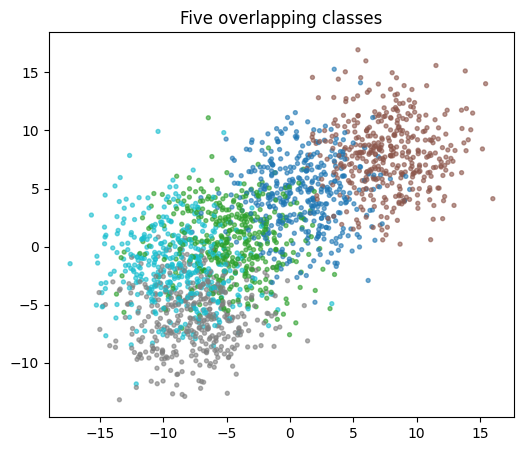

In [2]:
X, y = make_blobs(
    n_samples=2000, centers=5, n_features=2, cluster_std=3.0, random_state=3
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", s=8, alpha=0.6)
ax.set_title("Five overlapping classes")
plt.show()

## Approach 1: SomClassifier

The supervised SOM grows its map on the labelled data. Prototype positions are driven by the same unsupervised update as `SomVQ` — labels only enter through majority-vote prototype labelling, so this is the density-based baseline.

In [3]:
clf = SomClassifier(
    random_state=4, n_iter=300, max_neurons=60, lambda_=5, verbose=False, sigma_end=0.5
).fit(X_train, y_train)
acc_clf = (clf.predict(X_test) == y_test).mean()
print(f"prototypes: {clf.som_.number_of_nodes()}")
print(f"SomClassifier accuracy: {acc_clf:.4f}")

prototypes: 57
SomClassifier accuracy: 0.6983


## Approach 2: Batch LVQ-SOM Refinement

`BatchLvqSom` takes the fitted `SomClassifier` and iterates the signed batch update: each prototype becomes the neighborhood-weighted mean of its samples, where same-class samples count positive and other-class samples negative. Node labels are re-voted each iteration.

In [4]:
lvq = BatchLvqSom(n_iter=50).fit(X_train, y_train, clf)
acc_lvq = (lvq.predict(X_test) == y_test).mean()
print(f"Batch LVQ-SOM accuracy: {acc_lvq:.4f}")

Batch LVQ-SOM accuracy: 0.7217


## Decision Boundaries

Where the two approaches place their class boundaries. The LVQ panel should differ near class borders.

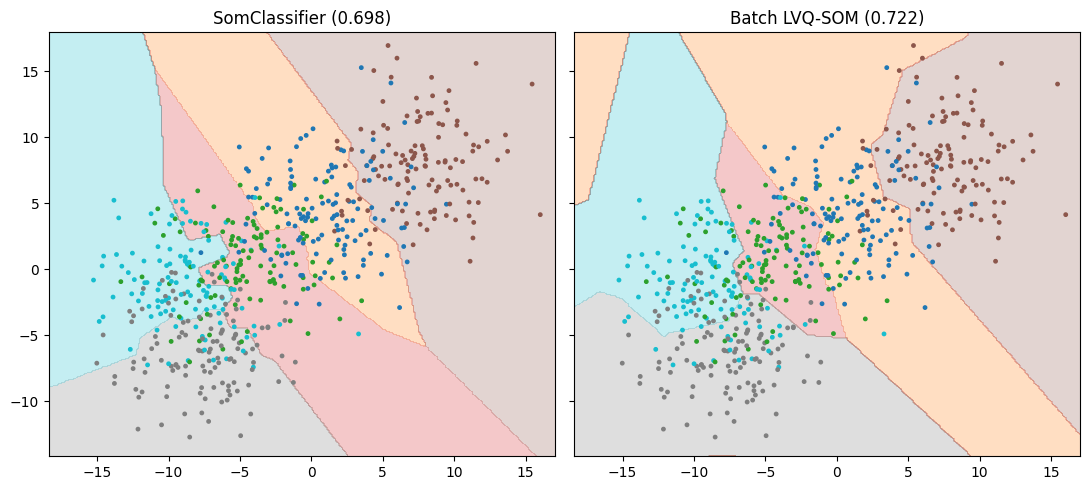

In [5]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]

predictions = {
    f"SomClassifier ({acc_clf:.3f})": clf.predict(grid),
    f"Batch LVQ-SOM ({acc_lvq:.3f})": lvq.predict(grid),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, (title, z) in zip(axes, predictions.items()):
    ax.contourf(xx, yy, z.reshape(xx.shape), cmap="tab10", alpha=0.25, levels=4)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="tab10", s=6)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Prototype Movement

How far the LVQ refinement moved each prototype. Prototypes deep inside a class barely move; prototypes near a boundary get pushed away from the other class. The occasional long jump is a prototype whose signed mean is dominated by repulsion (Kohonen's stability rule skips the update entirely when the signed denominator turns negative).

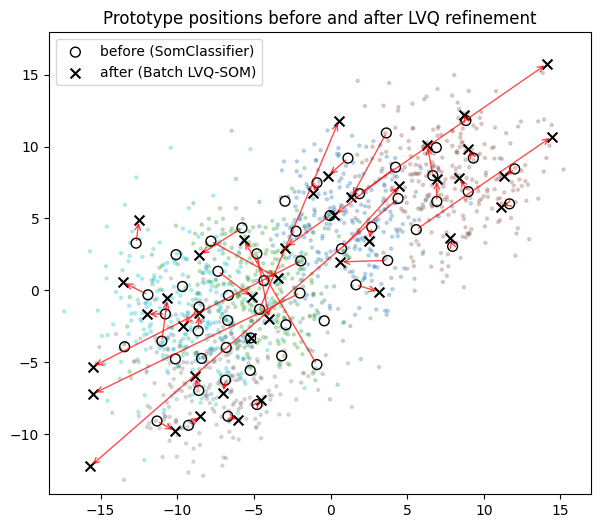

median movement: 3.688
max movement:    485.488


In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="tab10", s=5, alpha=0.25)
ax.scatter(
    clf.weights_[:, 0],
    clf.weights_[:, 1],
    marker="o",
    s=50,
    facecolors="none",
    edgecolors="black",
    label="before (SomClassifier)",
)
ax.scatter(
    lvq.weights_[:, 0],
    lvq.weights_[:, 1],
    marker="x",
    s=50,
    c="black",
    label="after (Batch LVQ-SOM)",
)
for before, after in zip(clf.weights_, lvq.weights_):
    ax.annotate(
        "",
        xy=after,
        xytext=before,
        arrowprops=dict(arrowstyle="->", color="red", lw=1, alpha=0.7),
    )
ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
ax.set_title("Prototype positions before and after LVQ refinement")
ax.legend()
plt.show()

movement = np.linalg.norm(lvq.weights_ - clf.weights_, axis=1)
print(f"median movement: {np.median(movement):.3f}")
print(f"max movement:    {movement.max():.3f}")

## Summary

Same prototypes, same topology — the only difference is the supervised refinement step. `SomClassifier` places prototypes by density alone; the batch LVQ-SOM update moves boundary prototypes and gains an edge on overlapping classes. The gain is modest because most of the remaining error is irreducible class overlap, not misplaced boundaries.

SomClassifier        0.6983
Batch LVQ-SOM        0.7217


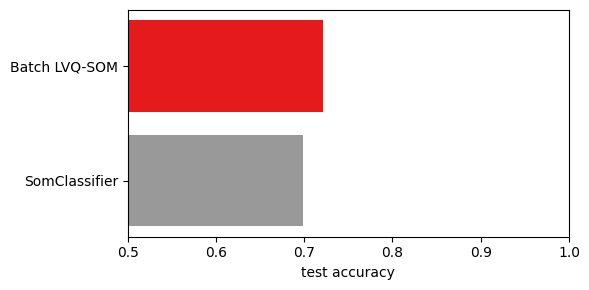

In [7]:
results = {
    "SomClassifier": acc_clf,
    "Batch LVQ-SOM": acc_lvq,
}
for name, acc in results.items():
    print(f"{name:<20} {acc:.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(list(results), list(results.values()), color=["#999", "#e41a1c"])
ax.set_xlim(0.5, 1)
ax.set_xlabel("test accuracy")
plt.tight_layout()
plt.show()